# Entraînement PPO

Ce notebook permet de lancer l'entraînement PPO et de visualiser en temps réel l'évolution des métriques.

In [ ]:
import sys
sys.path.append('../onitama/')

import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import clear_output

from dl_players_v6 import CNNPlayer_v6
from game import GameSession
from players import HeuristicPlayer, LookAheadHeuristicPlayer
from ppo import PPOTrainer

%matplotlib inline

2026-04-15 22:55:26.097526: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-15 22:55:26.098656: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-15 22:55:28.015396: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-15 22:55:28.912321: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computat

## Configuration

In [ ]:
dst_model_name = "kamae-training-ppo"
PRETRAINED_WEIGHTS = '../models/weights/Kamae4.weights.h5'
SAVE_PATH = f"../models/training/{dst_model_name}.weights.h5"

N_ITERATIONS = 750
N_GAMES = 128
N_EPOCHS = 4
MINIBATCH_SIZE = 64
LEARNING_RATE = 1e-4
CLIP_EPSILON = 0.1
VALUE_COEF = 0.5
ENTROPY_COEF = 0.01
GAMMA = 0.99
LAM = 0.95
SAVE_EVERY = 10

# Fréquence de mise à jour des graphiques (toutes les N itérations)
PLOT_EVERY = 1

#Fréquence de réalisation d'un test d'efficience du réseau
EFFICIENCY_EVERY = 10
EFFICIENCY_NB_GAMES = 200


## Initialisation du modèle et du trainer

In [3]:
p1 = CNNPlayer_v6()
p1.load_weights(PRETRAINED_WEIGHTS)
p2 = CNNPlayer_v6()

p2_alt1 = LookAheadHeuristicPlayer(max_depth=1, heuristic_function="heuristic_defensive")
p2_alt2 = LookAheadHeuristicPlayer(max_depth=2, heuristic_function="heuristic_defensive")
p2_alt3 = LookAheadHeuristicPlayer(max_depth=3, heuristic_function="heuristic_aggressive")

trainer = PPOTrainer(
    player1=p1,
    player2=p2,
    n_games=N_GAMES,
    n_epochs=N_EPOCHS,
    minibatch_size=MINIBATCH_SIZE,
    learning_rate=LEARNING_RATE,
    clip_epsilon=CLIP_EPSILON,
    value_coef=VALUE_COEF,
    entropy_coef=ENTROPY_COEF,
    gamma=GAMMA,
    lam=LAM,
    alternative_players=[p2_alt2, p2_alt1, p2_alt3],
    alternative_players_ratio=[10, 20, 50]
)

print("Modèle et trainer initialisés.")

2026-04-15 22:57:36.617104: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Modèle et trainer initialisés.


In [ ]:
efficiency_p2 = []
efficiency_p3 = []
efficiency_iters = []

#Retourne un callback qui met à jour les graphiques après chaque itération.
def make_plot_callback(n_iterations, plot_every=1, effencieny_every=1):

    def _moving_avg(values, w=10):
        if len(values) < w:
            return None, None
        kernel = np.ones(w) / w
        return list(range(w, len(values) + 1)), np.convolve(values, kernel, mode='valid')

    def plot_callback(iteration, metrics, history):
        if iteration % plot_every != 0 and iteration != n_iterations:
            return
        
        if iteration % effencieny_every == 0:
            #Test d'efficacité après N iterations
            
            iter = math.floor(iteration/SAVE_EVERY)*SAVE_EVERY
            model_file = PRETRAINED_WEIGHTS
            if iter > 0:
                model_file = f"{SAVE_PATH}_iter{iter}.weights.h5"
            p1_test = CNNPlayer_v6()
            p1_test.load_weights(model_file)

            print(f"Test d'efficacité - modèle {model_file}")

            p2 = HeuristicPlayer(heuristic_function="heuristic_defensive")
            gameSession = GameSession(player_one=p1_test, player_two=p2, number_of_games=EFFICIENCY_NB_GAMES)
            gameSession.start()
            stats = gameSession.getStats()
            ratio_p2 = float(stats['p1_win']/EFFICIENCY_NB_GAMES)
            efficiency_p2.append(ratio_p2)

            p3 = LookAheadHeuristicPlayer(heuristic_function="heuristic_defensive", max_depth=2)
            gameSession = GameSession(player_one=p1_test, player_two=p3, number_of_games=EFFICIENCY_NB_GAMES)
            gameSession.start()
            stats = gameSession.getStats()
            ratio_p3 = float(stats['p1_win']/EFFICIENCY_NB_GAMES)
            efficiency_p3.append(ratio_p3)

            efficiency_iters.append(iteration)
            

        iters = list(range(1, iteration + 1))

        clear_output(wait=True)

        fig = plt.figure(figsize=(16, 10))
        fig.suptitle(f'Entraînement PPO — Itération {iteration}/{n_iterations}', fontsize=14, fontweight='bold')
        gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.4, wspace=0.35)

        #Policy loss
        ax1 = fig.add_subplot(gs[0, 0])
        ax1.plot(iters, history['policy_loss'], color='steelblue', linewidth=1, alpha=0.5)
        iters_s, smooth_pl = _moving_avg(history['policy_loss'])
        if iters_s is not None:
            ax1.plot(iters_s, smooth_pl, color='steelblue', linewidth=2, linestyle='--')
        ax1.set_title('Policy Loss')
        ax1.set_xlabel('Itération')
        ax1.set_ylabel('Loss')
        ax1.grid(True, alpha=0.3)

        #Value loss
        ax2 = fig.add_subplot(gs[0, 1])
        ax2.plot(iters, history['value_loss'], color='darkorange', linewidth=1, alpha=0.5)
        iters_s, smooth_vl = _moving_avg(history['value_loss'])
        if iters_s is not None:
            ax2.plot(iters_s, smooth_vl, color='darkorange', linewidth=2, linestyle='--')
        ax2.set_title('Value Loss')
        ax2.set_xlabel('Itération')
        ax2.set_ylabel('Loss')
        ax2.grid(True, alpha=0.3)

        #Entropie
        ax3 = fig.add_subplot(gs[0, 2])
        ax3.plot(iters, history['entropy'], color='seagreen', linewidth=1, alpha=0.5)
        iters_s, smooth_ent = _moving_avg(history['entropy'])
        if iters_s is not None:
            ax3.plot(iters_s, smooth_ent, color='seagreen', linewidth=2, linestyle='--')
        ax3.set_title('Entropie (exploration)')
        ax3.set_xlabel('Itération')
        ax3.set_ylabel('Entropie')
        ax3.grid(True, alpha=0.3)

        #Victoires / Défaites / Nuls
        ax4 = fig.add_subplot(gs[1, 0:2])
        wins = np.array(history['wins'])
        losses = np.array(history['losses'])
        draws = np.array(history['draws'])
        total = wins + losses + draws
        safe_total = np.where(total == 0, 1, total)
        win_pct = wins / safe_total * 100
        loss_pct = losses / safe_total * 100
        draw_pct = draws / safe_total * 100

        ax4.stackplot(iters, win_pct, draw_pct, loss_pct,
                      labels=['Victoires', 'Nuls', 'Défaites'],
                      colors=['#4caf50', '#ff9800', '#f44336'],
                      alpha=0.75)
        ax4.set_title('Résultats des parties (%)')
        ax4.set_xlabel('Itération')
        ax4.set_ylabel('%')
        ax4.set_ylim(0, 100)
        ax4.legend(loc='upper right', fontsize=9)
        ax4.grid(True, alpha=0.2)

        #Transitions collectées
        ax5 = fig.add_subplot(gs[1, 2])
        ax5.bar(iters, history['transitions'], color='slategray', alpha=0.7, width=0.8)
        ax5.set_title('Transitions collectées')
        ax5.set_xlabel('Itération')
        ax5.set_ylabel('Nombre')
        ax5.grid(True, alpha=0.3, axis='y')

        #Efficacité fac à des adversaires heuristiques (niv 1)
        ax6 = fig.add_subplot(gs[2, 0])
        ax6.plot(efficiency_iters, efficiency_p2, color='steelblue', linewidth=1.5)
        ax6.set_title('Efficiency (heuristic player [defensive])')
        ax6.set_xlabel('Itération')
        ax6.set_ylabel('Ratio wins')
        ax6.grid(True, alpha=0.3)

        #Efficacité fac à des adversaires heuristiques (niv 2)
        ax7 = fig.add_subplot(gs[2, 1])
        ax7.plot(efficiency_iters, efficiency_p3, color='steelblue', linewidth=1.5)
        ax7.set_title('Efficiency (LookAhead2 euristic player [defensive])')
        ax7.set_xlabel('Itération')
        ax7.set_ylabel('Ratio wins')
        ax7.grid(True, alpha=0.3)

        plt.show()

    return plot_callback

## Entraînement PPO

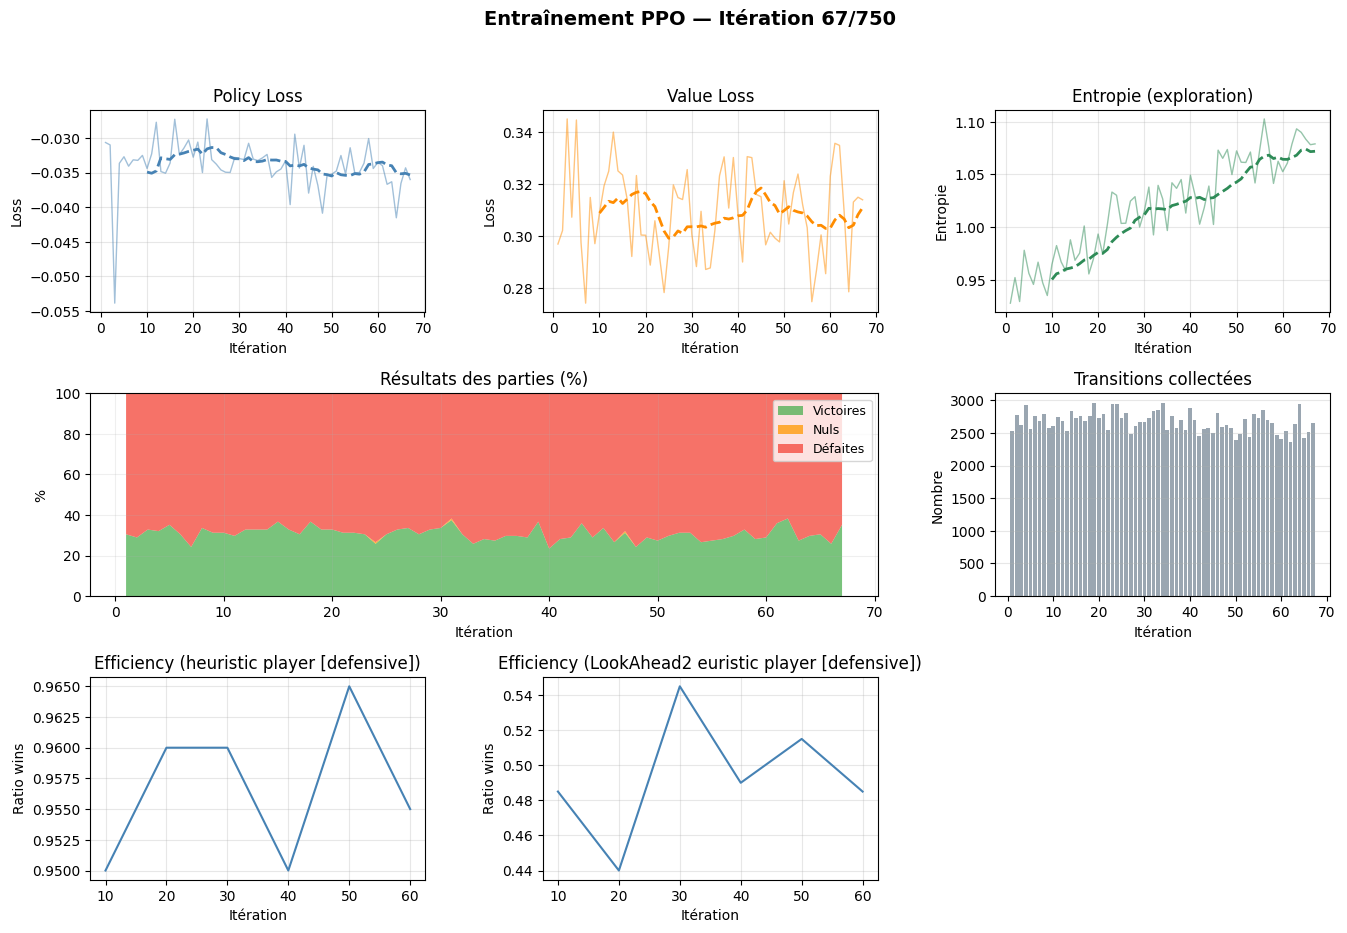

self-play:  50%|█████     | 64/128 [02:21<02:21,  2.22s/it]


KeyboardInterrupt: 

In [5]:
callback = make_plot_callback(n_iterations=N_ITERATIONS, plot_every=PLOT_EVERY, effencieny_every=EFFICIENCY_EVERY)

history = trainer.train(
    n_iterations=N_ITERATIONS,
    save_every=SAVE_EVERY,
    save_path=SAVE_PATH,
    on_iteration_end=callback
)

print("\nEntraînement terminé !")